<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Portfolio_Analysis_%26_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Portfolio Analysis & Optimization
import numpy as np
 # --- Asset Parameters ---
mu_A , sigma_A = 0.12 , 0.20 # Stocks
mu_B , sigma_B = 0.06 , 0.10 # Bonds
rho = 0.30 # Correlation
rf = 0.04 # Risk - free rate

def portfolio_stats (w_A , mu_A , sigma_A , mu_B , sigma_B , rho ):
# """ Compute portfolio return and risk ."""
 w_B = 1 - w_A
 ret = w_A * mu_A + w_B * mu_B
 var = (w_A **2 * sigma_A **2 + w_B **2 * sigma_B **2 + 2* w_A *w_B* sigma_A * sigma_B *rho)
 risk = np. sqrt ( var)
 return ret , risk


In [9]:
# === 1. Vary weights from 0% to 100% stocks ===
print ("=" * 55)
print ("2- ASSET PORTFOLIO ANALYSIS ")
print ("=" * 55)
print (f"\nStocks : mu ={ mu_A :.0%} , sigma ={ sigma_A :.0%} ")
print (f" Bonds : mu ={ mu_B :.0%} , sigma ={ sigma_B :.0%} ")
print (f" Correlation : {rho }")
print (f"\n{' w_Stock ':>8} {' Return ':>8} {' Risk ':>8} "
f"{' Sharpe ':>8}")
print ("-" * 36)
best_sharpe = -999
best_w = 0
for w in np. arange (0, 1.01 , 0.1) :
  ret , risk = portfolio_stats (w, mu_A , sigma_A , mu_B , sigma_B , rho )
  sharpe = ( ret - rf) / risk if risk > 0 else 0
  print (f"{w : >7.0%} { ret : >8.2%} { risk : >8.2%} "
f"{ sharpe : >8.3f}")
  if sharpe > best_sharpe :
    best_sharpe = sharpe
    best_w = w
  print (f"\nOptimal (max Sharpe ): { best_w :.0%} stocks , "
  f" Sharpe = { best_sharpe :.3f}")

2- ASSET PORTFOLIO ANALYSIS 

Stocks : mu =12% , sigma =20% 
 Bonds : mu =6% , sigma =10% 
 Correlation : 0.3

 w_Stock   Return     Risk   Sharpe 
------------------------------------
     0%    6.00%   10.00%    0.200

Optimal (max Sharpe ): 0% stocks ,  Sharpe = 0.200
    10%    6.60%    9.79%    0.266

Optimal (max Sharpe ): 10% stocks ,  Sharpe = 0.266
    20%    7.20%    9.96%    0.321

Optimal (max Sharpe ): 20% stocks ,  Sharpe = 0.321
    30%    7.80%   10.50%    0.362

Optimal (max Sharpe ): 30% stocks ,  Sharpe = 0.362
    40%    8.40%   11.35%    0.388

Optimal (max Sharpe ): 40% stocks ,  Sharpe = 0.388
    50%    9.00%   12.45%    0.402

Optimal (max Sharpe ): 50% stocks ,  Sharpe = 0.402
    60%    9.60%   13.74%    0.408

Optimal (max Sharpe ): 60% stocks ,  Sharpe = 0.408
    70%   10.20%   15.17%    0.409

Optimal (max Sharpe ): 70% stocks ,  Sharpe = 0.409
    80%   10.80%   16.71%    0.407

Optimal (max Sharpe ): 70% stocks ,  Sharpe = 0.409
    90%   11.40%   18.32

In [12]:
# === 2. Minimum Variance Portfolio ===
# Analytical solution : w_A = ( sigB ^2 - rho * sigA * sigB )
# / ( sigA ^2 + sigB ^2 - 2* rho* sigA * sigB )
w_mv = ( sigma_B **2 - rho* sigma_A * sigma_B ) / \
  ( sigma_A **2 + sigma_B **2
 - 2* rho* sigma_A * sigma_B )
ret_mv , risk_mv = portfolio_stats (
w_mv , mu_A , sigma_A , mu_B , sigma_B , rho)
print (f"\nMinimum Variance Portfolio :")
print (f" w_Stock = { w_mv :.2%} ")
print (f" Return = { ret_mv :.2%} ")
print (f" Risk = { risk_mv :.2%} ")


Minimum Variance Portfolio :
 w_Stock = 10.53% 
 Return = 6.63% 
 Risk = 9.79% 


In [15]:
# === 3. Effect of Correlation ===
print (f"\n{' rho ':>5} {' MinVar_Risk ': >12} { '50/50 _Risk ': >12}")
print ("-" * 32)
for r in [-1.0 , -0.5 , 0.0 , 0.3 , 0.5 , 0.8 , 1.0]:
  _, risk_50 = portfolio_stats (
  0.5 , mu_A , sigma_A , mu_B , sigma_B , r)
  w_mv_r = ( sigma_B **2 - r* sigma_A * sigma_B ) / \
  ( sigma_A **2 + sigma_B **2
  - 2*r* sigma_A * sigma_B )
  w_mv_r = np. clip (w_mv_r , 0, 1)
  _, risk_mv_r = portfolio_stats (
  w_mv_r , mu_A , sigma_A , mu_B , sigma_B , r)
  print (f"{r: >5.1f} { risk_mv_r : >11.2%} "
  f"{ risk_50 : >11.2%} ")


 rho   MinVar_Risk  50/50 _Risk 
--------------------------------
 -1.0       0.00%       5.00% 
 -0.5       6.55%       8.66% 
  0.0       8.94%      11.18% 
  0.3       9.79%      12.45% 
  0.5      10.00%      13.23% 
  0.8      10.00%      14.32% 
  1.0      10.00%      15.00% 


### 4. Efficient Frontier Plot

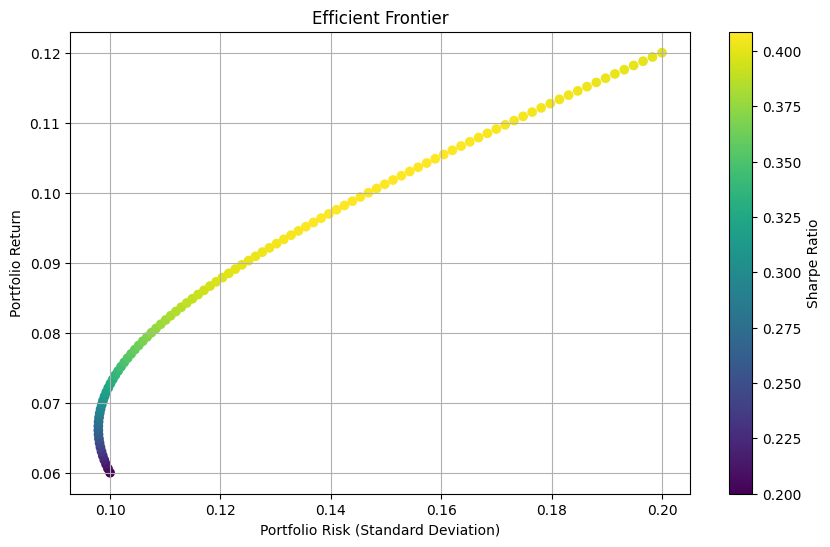

In [16]:
import matplotlib.pyplot as plt

# Generate a range of weights for asset A (stocks)
w_A_range = np.linspace(0, 1, 100) # 100 points from 0% to 100% stocks

# Initialize lists to store returns and risks
portfolio_returns = []
portfolio_risks = []

# Calculate returns and risks for each weight combination
for w_A in w_A_range:
    ret, risk = portfolio_stats(w_A, mu_A, sigma_A, mu_B, sigma_B, rho)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, c=(np.array(portfolio_returns) - rf) / np.array(portfolio_risks), cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.title('Efficient Frontier')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.grid(True)
plt.show()

In [17]:
# Calculate Sharpe ratio for each portfolio on the Efficient Frontier
sharpe_ratios = (np.array(portfolio_returns) - rf) / np.array(portfolio_risks)

print("First 10 Sharpe Ratios on the Efficient Frontier:")
for i in range(10):
    print(f"Portfolio {i+1}: {sharpe_ratios[i]:.3f}")

# You can also display the full array of Sharpe Ratios if needed
# print("\nAll Sharpe Ratios:")
# print(sharpe_ratios)

First 10 Sharpe Ratios on the Efficient Frontier:
Portfolio 1: 0.200
Portfolio 2: 0.207
Portfolio 3: 0.214
Portfolio 4: 0.220
Portfolio 5: 0.227
Portfolio 6: 0.234
Portfolio 7: 0.241
Portfolio 8: 0.247
Portfolio 9: 0.254
Portfolio 10: 0.260


### Plotting Sharpe Ratio vs. Portfolio Risk

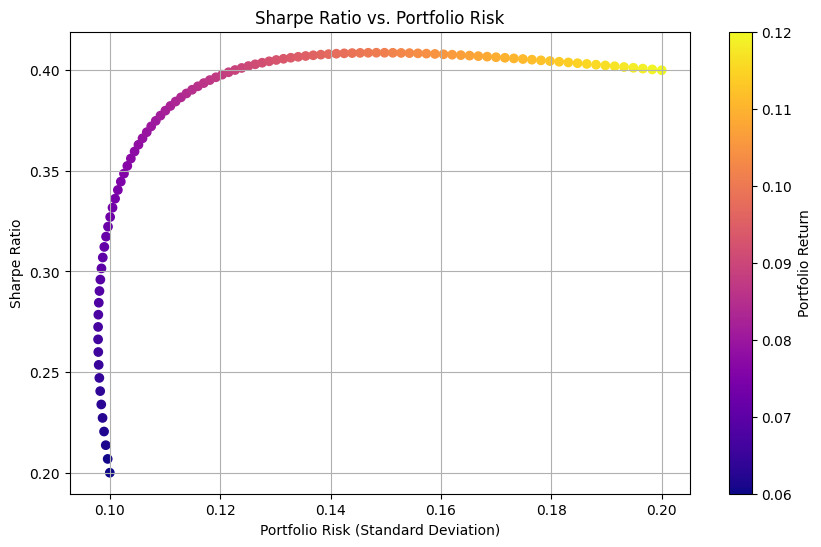

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, sharpe_ratios, c=portfolio_returns, cmap='plasma')
plt.colorbar(label='Portfolio Return')
plt.title('Sharpe Ratio vs. Portfolio Risk')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()

### Calculating the Tangency Portfolio

In [19]:
# The Tangency Portfolio is the portfolio with the highest Sharpe Ratio, which we already identified.
# The weight of stocks for the optimal (max Sharpe) portfolio is stored in `best_w`.

w_tangency_stocks = best_w
w_tangency_bonds = 1 - w_tangency_stocks

ret_tangency, risk_tangency = portfolio_stats(
    w_tangency_stocks, mu_A, sigma_A, mu_B, sigma_B, rho
)

print(f"Tangency Portfolio Weights:")
print(f"  Stocks: {w_tangency_stocks:.2%}")
print(f"  Bonds: {w_tangency_bonds:.2%}")
print(f"Tangency Portfolio Return: {ret_tangency:.2%}")
print(f"Tangency Portfolio Risk: {risk_tangency:.2%}")
print(f"Tangency Portfolio Sharpe Ratio: {best_sharpe:.3f}")

Tangency Portfolio Weights:
  Stocks: 70.00%
  Bonds: 30.00%
Tangency Portfolio Return: 10.20%
Tangency Portfolio Risk: 15.17%
Tangency Portfolio Sharpe Ratio: 0.409


### Calculating and Plotting the Capital Allocation Line (CAL)

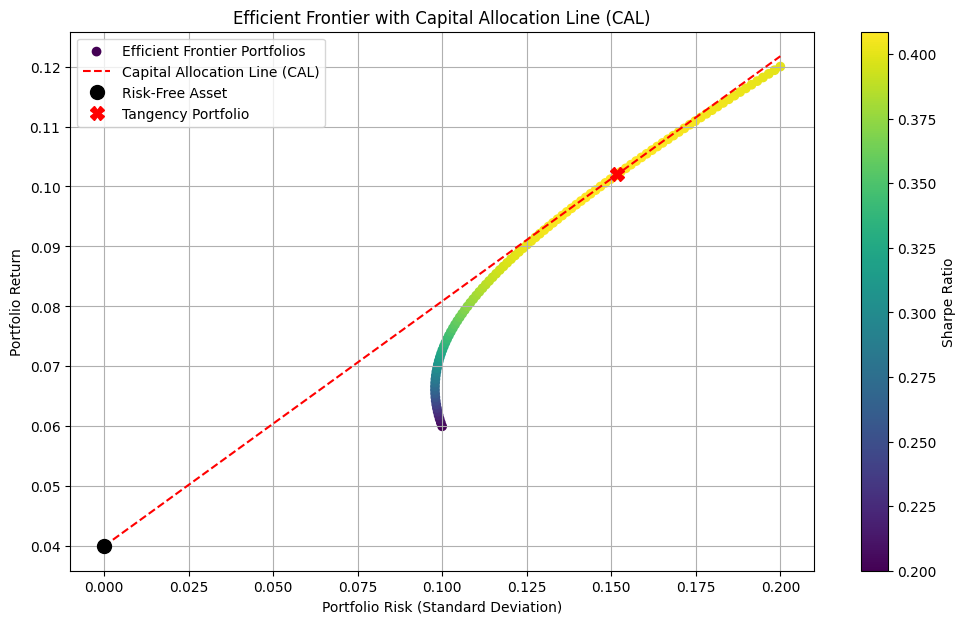

In [20]:
# Define the slope of the CAL (Sharpe Ratio of the Tangency Portfolio)
cal_slope = (ret_tangency - rf) / risk_tangency

# Create a range of risks for the CAL, starting from 0 (risk-free asset) up to the max portfolio risk
cal_risks = np.linspace(0, max(portfolio_risks), 100)

# Calculate corresponding returns for the CAL
cal_returns = rf + cal_slope * cal_risks

# Plot the Efficient Frontier and the CAL
plt.figure(figsize=(12, 7))
plt.scatter(portfolio_risks, portfolio_returns, c=(np.array(portfolio_returns) - rf) / np.array(portfolio_risks), cmap='viridis', label='Efficient Frontier Portfolios')
plt.plot(cal_risks, cal_returns, 'r--', label='Capital Allocation Line (CAL)')

# Mark the Risk-Free Asset and Tangency Portfolio
plt.plot(0, rf, 'o', markersize=10, color='black', label='Risk-Free Asset')
plt.plot(risk_tangency, ret_tangency, 'X', markersize=10, color='red', label='Tangency Portfolio')

plt.colorbar(label='Sharpe Ratio')
plt.title('Efficient Frontier with Capital Allocation Line (CAL)')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.grid(True)
plt.legend()
plt.show()

### Summary Table of Efficient Frontier Portfolio Statistics

In [21]:
import pandas as pd

# Create a DataFrame from the calculated portfolio statistics
efficient_frontier_df = pd.DataFrame({
    'Portfolio Return': portfolio_returns,
    'Portfolio Risk': portfolio_risks,
    'Sharpe Ratio': sharpe_ratios
})

# Display the first few rows of the summary table
print("Summary of Efficient Frontier Portfolio Statistics:")
display(efficient_frontier_df.head())

Summary of Efficient Frontier Portfolio Statistics:


,Portfolio Return,Portfolio Risk,Sharpe Ratio
0,0.060000,0.100000,0.200000
1,0.060606,0.099615,0.206858
2,0.061212,0.099267,0.213688
3,0.061818,0.098957,0.220482
4,0.062424,0.098685,0.227230


### Portfolio with the Highest Sharpe Ratio (Tangency Portfolio) from the Efficient Frontier DataFrame

In [22]:
# Find the index of the maximum Sharpe Ratio in the DataFrame
max_sharpe_portfolio_idx = efficient_frontier_df['Sharpe Ratio'].idxmax()

# Retrieve the portfolio details at that index
max_sharpe_portfolio = efficient_frontier_df.loc[max_sharpe_portfolio_idx]

print("Portfolio with the Highest Sharpe Ratio on the Efficient Frontier:")
display(max_sharpe_portfolio)

Portfolio with the Highest Sharpe Ratio on the Efficient Frontier:


,67
Portfolio Return,0.100606
Portfolio Risk,0.148292
Sharpe Ratio,0.408695


### Distribution of Sharpe Ratios

### Portfolio Risk vs. Portfolio Return Scatter Plot

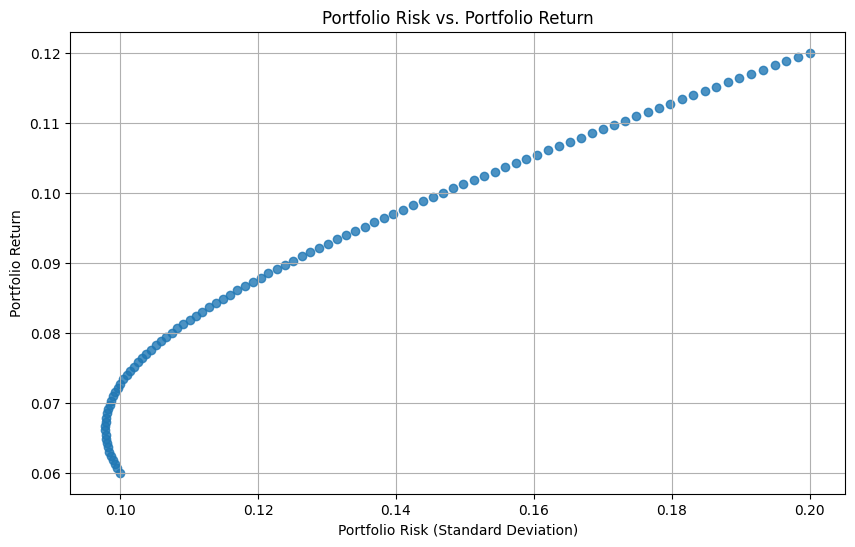

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, alpha=0.8)
plt.title('Portfolio Risk vs. Portfolio Return')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.grid(True)
plt.show()

### Portfolio Risk vs. Portfolio Return Scatter Plot with Max Sharpe Ratio Highlighted

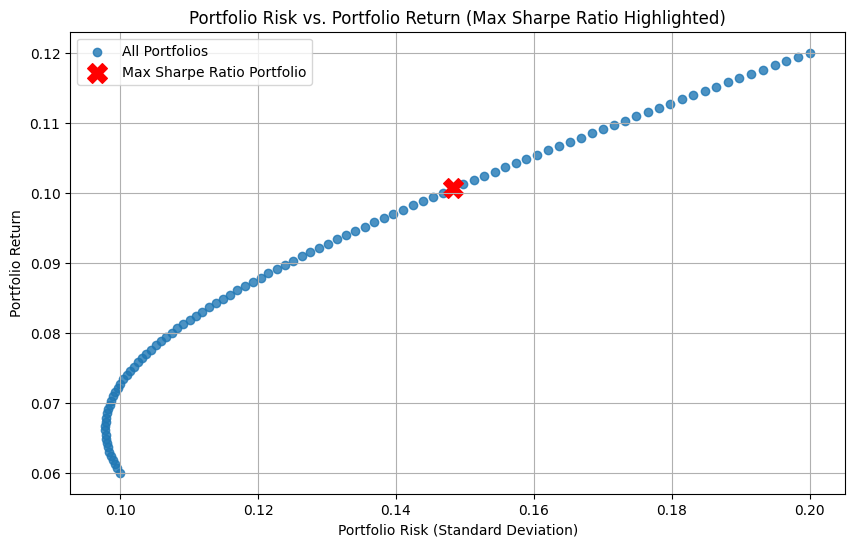

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(portfolio_risks, portfolio_returns, alpha=0.8, label='All Portfolios')

# Highlight the portfolio with the maximum Sharpe Ratio
max_sharpe_risk = efficient_frontier_df.loc[max_sharpe_portfolio_idx]['Portfolio Risk']
max_sharpe_return = efficient_frontier_df.loc[max_sharpe_portfolio_idx]['Portfolio Return']
plt.scatter(max_sharpe_risk, max_sharpe_return, color='red', marker='X', s=200, label='Max Sharpe Ratio Portfolio')

plt.title('Portfolio Risk vs. Portfolio Return (Max Sharpe Ratio Highlighted)')
plt.xlabel('Portfolio Risk (Standard Deviation)')
plt.ylabel('Portfolio Return')
plt.grid(True)
plt.legend()
plt.show()

### Correlation Matrix between Portfolio Return and Portfolio Risk

In [28]:
correlation_matrix = efficient_frontier_df[['Portfolio Return', 'Portfolio Risk']].corr()
display(correlation_matrix)

,Portfolio Return,Portfolio Risk
Portfolio Return,1.000000,0.969739
Portfolio Risk,0.969739,1.000000


### Top 5 Portfolios by Sharpe Ratio

In [29]:
# Sort the DataFrame by 'Sharpe Ratio' in descending order and select the top 5
top_5_sharpe_portfolios = efficient_frontier_df.sort_values(by='Sharpe Ratio', ascending=False).head(5)

print("Summary of Top 5 Portfolios by Sharpe Ratio:")
display(top_5_sharpe_portfolios)

Summary of Top 5 Portfolios by Sharpe Ratio:


,Portfolio Return,Portfolio Risk,Sharpe Ratio
67,0.100606,0.148292,0.408695
68,0.101212,0.149777,0.408690
66,0.100000,0.146818,0.408669
69,0.101818,0.151273,0.408654
65,0.099394,0.145356,0.408609


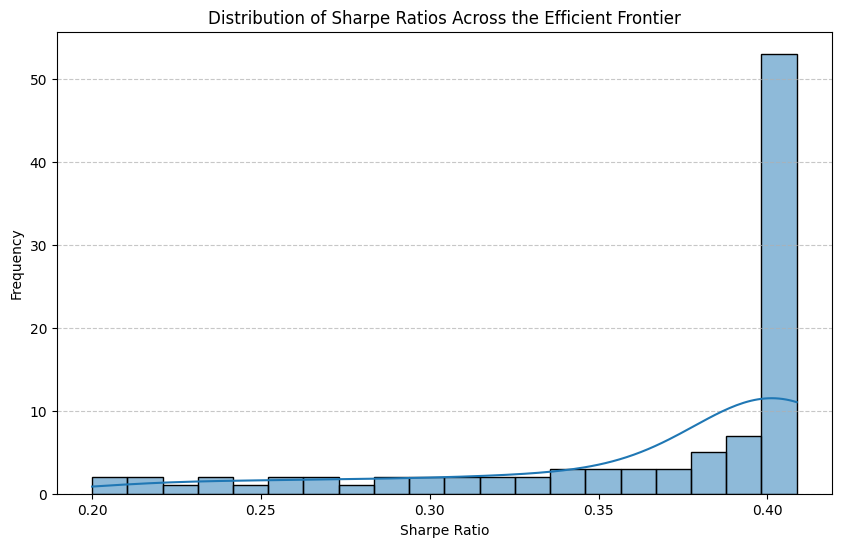

In [25]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(efficient_frontier_df['Sharpe Ratio'], bins=20, kde=True)
plt.title('Distribution of Sharpe Ratios Across the Efficient Frontier')
plt.xlabel('Sharpe Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
# === 4. Diversification Benefit ===
print (f"\n--- Diversification Benefit ---")
weighted_avg_risk = 0.5 * sigma_A + 0.5 * sigma_B
_, actual_risk = portfolio_stats (
0.5 , mu_A , sigma_A , mu_B , sigma_B , rho)
benefit = weighted_avg_risk - actual_risk
print (f" Weighted avg risk : { weighted_avg_risk :.2%} ")
print (f" Actual portfolio : { actual_risk :.2%} ")
print (f" Benefit ( free !): { benefit :.2%} ")
print (f" Reduction : "
f"{ benefit / weighted_avg_risk :.1%} ")



--- Diversification Benefit ---
 Weighted avg risk : 15.00% 
 Actual portfolio : 12.45% 
 Benefit ( free !): 2.55% 
 Reduction : 17.0% 


In [31]:
# === 5. Loss Recovery Table ( from Ch. 2) ===
print ("\n--- Sharpe Ratio Reality Check ---")
scenarios = [
("S&P 500 ( long -run)", 0.10 , 0.15 , 0.03) ,
(" Hedge Fund ( good )", 0.15 , 0.10 , 0.03) ,
(" Hedge Fund (avg )", 0.08 , 0.12 , 0.03) ,
(" Risky single stock ", 0.20 , 0.40 , 0.03) ,
]
for name , mu , sig , rf_rate in scenarios :
 sr = (mu - rf_rate ) / sig
 print (f" { name : <25} Sharpe = {sr :.2f}")


--- Sharpe Ratio Reality Check ---
 S&P 500 ( long -run)      Sharpe = 0.47
  Hedge Fund ( good )      Sharpe = 1.20
  Hedge Fund (avg )        Sharpe = 0.42
  Risky single stock       Sharpe = 0.42
